In [1]:
#packages
%pip install pandas geopandas scikit-learn matplotlib folium libpysal mapclassify

   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/882.2 kB ? eta -:--:--
   ----------------------------------- ---- 786.4/882.2 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 882.2/882.2 kB 1.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.1 MB 1.9 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.1 MB 2.1 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.1 MB 1.9 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 1.7 MB/s  0:00:01

   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
df = pd.read_csv('kc_house_data.csv') 

In [3]:
#see first five rows for feel of cols
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
#how many missing vals
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [5]:
#descriptive stats
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [6]:
#count dupes
df.duplicated().sum()

np.int64(0)

In [7]:
#total houses
total_houses = len(df)
print(f"Total number of houses: {total_houses}")

Total number of houses: 21613


In [8]:
#price

pQ1 = df['price'].quantile(0.25)
pQ3 = df['price'].quantile(0.75)
pIQR = pQ3 - pQ1

plower_fence = pQ1 - (1.5 * pIQR)
pupper_fence = pQ3 + (1.5 * pIQR)

plow_outliers = df[df['price'] < plower_fence]
phigh_outliers  = df[df['price'] > pupper_fence]
print(f"Low price outliers: {len(plow_outliers)}")
print(f"High price outliers: {len(phigh_outliers)}")

#just mark top 1%
upper_price = df['price'].quantile(0.99)
price_outliers = df[df['price'] > upper_price]
price_count = len(price_outliers)
print(f"Number of price-related outliers for removal: {price_count}")
#print(price_outliers)
df_clean = df[df['price'] <= upper_price]


Low price outliers: 0
High price outliers: 1146
Number of price-related outliers for removal: 217


In [9]:
#sqft_living

slQ1 = df['sqft_living'].quantile(0.25)
slQ3 = df['sqft_living'].quantile(0.75)
slIQR = slQ3 - slQ1

sllower_fence = slQ1 - (1.5 * slIQR)
slupper_fence = slQ3 + (1.5 * slIQR)

sllow_outliers = df[df['sqft_living'] < sllower_fence]
slhigh_outliers  = df[df['sqft_living'] > slupper_fence]
print(f"Low sqft_living outliers: {len(sllow_outliers)}")
print(f"High sqft_living outliers: {len(slhigh_outliers)}")

#just mark top 1%
upper_sqft_living = df['sqft_living'].quantile(0.99)
sqft_living_outliers = df[df['sqft_living'] > upper_sqft_living]
sqft_living_count = len(sqft_living_outliers)
print(f"Number of sqft_living-related outliers for removal: {sqft_living_count}")
#print(sqft_living_outliers)
df_clean = df_clean[df_clean['sqft_living'] <= upper_sqft_living]


Low sqft_living outliers: 0
High sqft_living outliers: 572
Number of sqft_living-related outliers for removal: 217


In [10]:
#sqft_lot

stQ1 = df['sqft_lot'].quantile(0.25)
stQ3 = df['sqft_lot'].quantile(0.75)
stIQR = stQ3 - stQ1

stlower_fence = stQ1 - (1.5 * stIQR)
stupper_fence = stQ3 + (1.5 * stIQR)

stlow_outliers = df[df['sqft_lot'] < stlower_fence]
sthigh_outliers  = df[df['sqft_lot'] > stupper_fence]
print(f"Low sqft_lot outliers: {len(stlow_outliers)}")
print(f"High sqft_lot outliers: {len(sthigh_outliers)}")

#just mark top 1%
upper_sqft_lot = df['sqft_lot'].quantile(0.99)
sqft_lot_outliers = df[df['sqft_lot'] > upper_sqft_lot]
sqft_lot_count = len(sqft_lot_outliers)
print(f"Number of sqft_lot-related outliers for removal: {sqft_lot_count}")
#print(sqft_lot_outliers)
df_clean = df_clean[df_clean['sqft_lot'] <= upper_sqft_lot]


Low sqft_lot outliers: 0
High sqft_lot outliers: 2425
Number of sqft_lot-related outliers for removal: 212


In [11]:
#bedrooms and bathrooms

df_clean = df_clean[(df_clean['bathrooms'] > 0) & 
              (df_clean['bedrooms'] > 0) & 
              (df_clean['bedrooms'] <= 12)]

print(f"Original row count: {len(df)}")
print(f"New clean row count: {len(df_clean)}")
print(f"Total rows removed: {len(df) - len(df_clean)}")


Original row count: 21613
New clean row count: 21056
Total rows removed: 557


In [12]:
df_clean.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [13]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 21056 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21056 non-null  int64  
 1   date           21056 non-null  str    
 2   price          21056 non-null  float64
 3   bedrooms       21056 non-null  int64  
 4   bathrooms      21056 non-null  float64
 5   sqft_living    21056 non-null  int64  
 6   sqft_lot       21056 non-null  int64  
 7   floors         21056 non-null  float64
 8   waterfront     21056 non-null  int64  
 9   view           21056 non-null  int64  
 10  condition      21056 non-null  int64  
 11  grade          21056 non-null  int64  
 12  sqft_above     21056 non-null  int64  
 13  sqft_basement  21056 non-null  int64  
 14  yr_built       21056 non-null  int64  
 15  yr_renovated   21056 non-null  int64  
 16  zipcode        21056 non-null  int64  
 17  lat            21056 non-null  float64
 18  long           21056 n

In [14]:
df_clean.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.105600e+04,2.105600e+04,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000,21056.000000
mean,4.614140e+09,5.121718e+05,3.354578,2.084002,2023.009498,11786.943627,1.486892,0.005272,0.207114,3.410952,7.604293,1743.033197,279.976301,1970.728628,82.272321,98078.616594,47.560193,-122.216198,1957.823756,11053.589428
std,2.876330e+09,2.765429e+05,0.893118,0.728511,809.493571,19152.497772,0.538954,0.072416,0.713735,0.650267,1.106295,753.049872,420.929033,29.352552,396.793848,53.581180,0.138647,0.139529,651.028940,19206.008336
min,1.000102e+06,7.800000e+04,1.000000,0.500000,370.000000,520.000000,1.000000,0.000000,0.000000,1.000000,3.000000,370.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.512000,399.000000,651.000000
25%,2.141311e+09,3.200000e+05,3.000000,1.500000,1410.000000,5000.000000,1.000000,0.000000,0.000000,3.000000,7.000000,1180.000000,0.000000,1951.000000,0.000000,98033.000000,47.470775,-122.330000,1480.000000,5060.000000
50%,3.959400e+09,4.460000e+05,3.000000,2.250000,1890.000000,7508.000000,1.000000,0.000000,0.000000,3.000000,7.000000,1540.000000,0.000000,1974.000000,0.000000,98070.000000,47.571500,-122.234000,1820.000000,7556.500000
75%,7.338402e+09,6.295750e+05,4.000000,2.500000,2500.000000,10336.000000,2.000000,0.000000,0.000000,4.000000,8.000000,2160.000000,540.000000,1996.000000,0.000000,98118.000000,47.678800,-122.128000,2330.000000,9900.000000
max,9.900000e+09,1.960000e+06,11.000000,7.500000,4970.000000,213008.000000,3.500000,1.000000,4.000000,5.000000,13.000000,4930.000000,2350.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,5790.000000,434728.000000


In [15]:
clean_houses = len(df_clean)
print(f"Total number of clean houses: {clean_houses}")

Total number of clean houses: 21056


In [16]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean.long, df_clean.lat), 
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=32148) 

In [17]:
from shapely.geometry import Point

#Downtown Seattle coords, WGS84
seattle_lon = -122.3321
seattle_lat = 47.6062

seattle_point = gpd.GeoSeries([Point(seattle_lon, seattle_lat)], crs="EPSG:4326")

seattle_projected = seattle_point.to_crs(epsg=32148).iloc[0]

gdf['dist_to_seattle_meters'] = gdf.geometry.distance(seattle_projected)

In [18]:
import libpysal

w = libpysal.weights.KNN.from_dataframe(gdf, k=10)

w.transform = 'r'

gdf['neighborhood_avg_price'] = libpysal.weights.lag_spatial(w, gdf['price'])

c:\Users\tuwil\Desktop\HousingProject\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [19]:
water_gdf = gpd.read_file('WTRBDY_DET_AREA_625_-4814799341421861538/Waterbodies_with_feature_history_and_jurisdictional_proximity.shp')

water_gdf = water_gdf.to_crs(epsg=32148)

gdf = gdf.reset_index(drop=True)
water_gdf = water_gdf.reset_index(drop=True)

#nearest_water = gpd.sjoin_nearest(gdf, water_gdf, distance_col='dist_to_water')

nearest_water = gpd.sjoin_nearest(gdf, water_gdf, how="inner", distance_col='dist_to_water')
nearest_water = nearest_water[~nearest_water.index.duplicated(keep='first')]

gdf['dist_to_water_meters'] = nearest_water['dist_to_water']

In [20]:
X = gdf.drop(columns=['price', 'geometry', 'date', 'id'])
y = gdf['price']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [23]:
from sklearn.metrics import mean_absolute_error, r2_score

predictions = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R-Squared Score: {r2:.3f}")

Mean Absolute Error: $62,729.46
R-Squared Score: 0.870


In [24]:
results_df = X_test.copy()

results_df['Actual_Price'] = y_test
results_df['Predicted_Price'] = predictions

results_df['Error'] = results_df['Predicted_Price'] - results_df['Actual_Price']

In [25]:
import geopandas as gpd

results_gdf = gpd.GeoDataFrame(results_df, geometry=gdf.loc[results_df.index, 'geometry'])

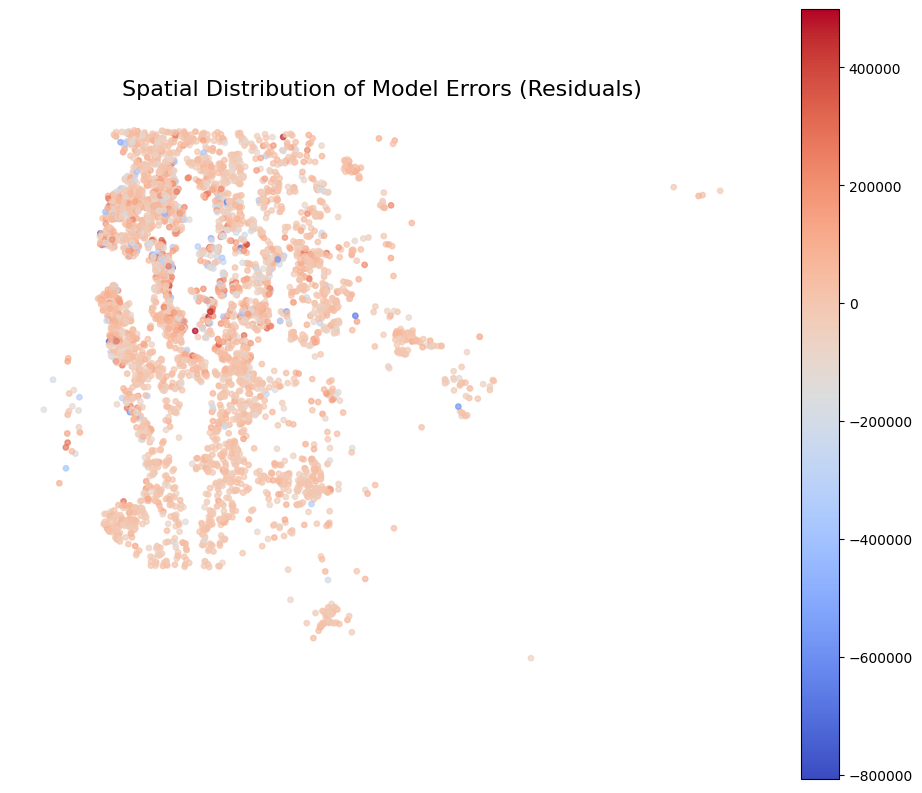

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

results_gdf.plot(column='Error', 
                 cmap='coolwarm', 
                 legend=True, 
                 markersize=15, 
                 alpha=0.7, 
                 ax=ax)

ax.set_title('Spatial Distribution of Model Errors (Residuals)', fontsize=16)
ax.set_axis_off()

plt.show()



In [27]:
interactive_map = results_gdf.explore(
    column='Error',               # Color the dots based on the Error amount
    cmap='coolwarm',              # Blue for under-priced, Red for over-priced
    marker_type='circle',         # Use circle markers
    marker_kwds={'radius': 50},   # Set the radius of the circles
    legend=True,                  # Show the color scale legend
    tiles='CartoDB positron',     # Use a clean, modern background map
    tooltip=['Actual_Price', 'Predicted_Price', 'Error'], # What shows up when you hover!
    name="Random Forest Residuals"
)

interactive_map

interactive_map.save("seattle_model_errors.html")